# Module 3 — Funnel Analysis *(recap)*

Part of the Product Analytics Playbook. Program and progress: [CURRICULUM.md](CURRICULUM.md).

## Why you're here: what this module is for

Funnel analysis is covered in depth in two earlier repos. This module is a short recap: the idea, what those repos showed (with their printed numbers and links), and one compact funnel on this playbook's store data. The new point here: the same funnel gives very different answers when counted per user or per session.

## From the curriculum

> ## <u>Module 3 — Funnel Analysis</u> *(recap)*
>
> **Covered in:**
> - A/B Testing Playbook,
>   [`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb),
>   "Part 1 — Funnel decomposition (the worked example, simulated at user level)"
> - Product Analytics Case Study,
>   [`03_Engagement_and_Retention.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/03_Engagement_and_Retention.ipynb),
>   "The funnel"
>
> **Recap:** step conversion vs. overall conversion; decomposing a top-line rate
> into steps, so a step that moves the wrong way isn't hidden.
>
> **Compact recompute:** view → cart → purchase on the running dataset,
> user-level vs. session-level (19% of purchasing sessions contain no cart
> event, so the two disagree).

## Recap

**Definitions:**
- A **funnel** is a sequence of steps people are expected to go through, e.g. view a product → add it to the cart → buy. It can be counted per user, per session, or per any other **unit**.
- **Step conversion** = units that reach a step ÷ units that reached the step before it.
- **Overall conversion** = units that reach the last step ÷ units that reached the first step. (The curriculum calls it the "top-line rate".)

**Why split a funnel into steps:** one overall rate can hide a step that moves the wrong way. If an earlier step improves and a later one gets worse, the overall rate can look unchanged.

### What the earlier repos showed

All numbers in this section are quoted from those notebooks' printed outputs.

**1. A/B Testing Playbook,** [`02_b2c_product_metrics.ipynb`](https://github.com/omri-sabag83/A-B-Testing-Playbook/blob/main/02_b2c_product_metrics.ipynb), section "Part 1 — Funnel decomposition (the worked example, simulated at user level)". Simulated data, 20,000 users per group:

| step | control | new onboarding flow |
|---|---|---|
| activation rate | 0.407 | 0.482 |
| Day-7 retention of the activated | 0.600 | 0.508 |
| overall (activation × retention) | 0.407 × 0.600 = 0.244 | 0.482 × 0.508 = 0.245 |

The overall rate is almost the same in both groups, yet the new flow lifted activation and lowered the retention of the users it activated. Only the split into steps shows it.

**2. Product Analytics Case Study,** [`03_Engagement_and_Retention.ipynb`](https://github.com/omri-sabag83/Product-Analytics-Case-Study/blob/main/03_Engagement_and_Retention.ipynb), section "The funnel". Real data from an online-learning platform, 32,593 course enrollments. Step definitions there: **ever engaged** = any activity on the platform; **activated** = active on 3 or more days in the first 14 days; **success** = final result Pass or Distinction.

| step | enrollments | % of registered | % of previous step |
|---|---|---|---|
| Registered | 32,593 | 100% | — |
| Ever engaged | 29,228 | 89.7% | 89.7% |
| Activated | 20,094 | 61.7% | 68.7% |
| Submitted at least 1 assessment | 19,071 | 58.5% | 94.9% |
| Success | 12,162 | 37.3% | 63.8% |

The biggest step loss there was Submitted → Success (63.8% made it), then Ever engaged → Activated (68.7%).

## Compact recompute: view → cart → purchase on this store's data

**Definitions:**
- Steps: **view** (opened a product page) → **cart** (added a product to the cart) → **purchase**.
- The funnel is counted for two units:
  - **per user:** over the whole five months, did the user ever do each step?
  - **per session:** within one logged `user_session`, did each step happen?
- A step counts only if all earlier steps also happened for the same user (or in the same session). The time order of the steps is not checked.

**Data limit, up front:** the "all earlier steps" rule leaves out some purchases. The output below shows how many: buyers missing a view or a cart add (or both), and purchase sessions missing a view or a cart add (or both) in that session.

In [1]:
import pandas as pd
from common import connect, query, show, funnel_chart

con = connect()
ev = query(con, "SELECT user_id, user_session, event_type FROM events_clean")

def funnel_counts(df, unit):
    steps = df.groupby(unit)["event_type"].agg(set)
    view = steps.map(lambda s: "view" in s)
    cart = steps.map(lambda s: "cart" in s)
    buy = steps.map(lambda s: "purchase" in s)
    counts = pd.Series({"view": int(view.sum()), "view + cart": int((view & cart).sum()),
                        "view + cart + purchase": int((view & cart & buy).sum())})
    return counts, int(buy.sum()), int((buy & ~cart).sum())

users, users_buying, _ = funnel_counts(ev, "user_id")
sessions, sessions_buying, sessions_buying_no_cart = funnel_counts(ev.dropna(subset=["user_session"]), "user_session")

print("left out by the 'all earlier steps' rule:")
print(f"  per user:    {users_buying:,} buyers; {users_buying - users.iloc[-1]:,} of them "
      f"({(users_buying - users.iloc[-1]) / users_buying:.2%}) miss a view or a cart add (or both)")
print(f"  per session: {sessions_buying:,} purchase sessions; {sessions_buying - sessions.iloc[-1]:,} of them "
      f"({(sessions_buying - sessions.iloc[-1]) / sessions_buying:.2%}) miss a view or a cart add (or both) in that session")
print(f"               of which missing a cart add: {sessions_buying_no_cart:,} "
      f"({sessions_buying_no_cart / sessions_buying:.2%}; the 19% in the curriculum quote above counts this part only)")

left out by the 'all earlier steps' rule:
  per user:    10,899 buyers; 530 of them (4.86%) miss a view or a cart add (or both)
  per session: 15,277 purchase sessions; 4,763 of them (31.18%) miss a view or a cart add (or both) in that session
               of which missing a cart add: 2,899 (18.98%; the 19% in the curriculum quote above counts this part only)


**Observation:** per user, only 4.86% of buyers are left out. Per session, 31.18% of purchase sessions are.

In [2]:
compare = pd.DataFrame([
    ["view → cart", users.iloc[1] / users.iloc[0], sessions.iloc[1] / sessions.iloc[0]],
    ["cart → purchase", users.iloc[2] / users.iloc[1], sessions.iloc[2] / sessions.iloc[1]],
    ["overall: view → purchase", users.iloc[2] / users.iloc[0], sessions.iloc[2] / sessions.iloc[0]],
], columns=["step", "per user %", "per session %"])
compare["per user %"] = (compare["per user %"] * 100).map("{:.2f}".format)
compare["per session %"] = (compare["per session %"] * 100).map("{:.2f}".format)
print("counts:")
show(pd.DataFrame({"step": users.index, "users": users.map("{:,}".format).values,
                   "sessions": sessions.map("{:,}".format).values}))
print()
print("conversion:")
show(compare)

counts:
step                      users  sessions
view                    160,135   415,498
view + cart              35,921    77,894
view + cart + purchase   10,369    10,514

conversion:
step                      per user %  per session %
view → cart                    22.43          18.75
cart → purchase                28.87          13.50
overall: view → purchase        6.48           2.53


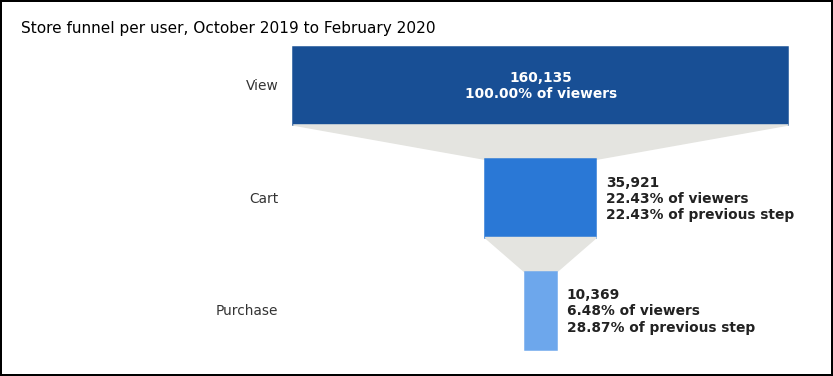

In [3]:
funnel_chart(users.rename(index={"view": "View", "view + cart": "Cart", "view + cart + purchase": "Purchase"}),
             "Store funnel per user, October 2019 to February 2020", "viewers")

**Observation:** per user, 22.43% of viewers add to cart and 28.87% of those buy, so 6.48% of viewers buy. Per session, cart → purchase is 13.50%, less than half the per-user rate, and the order of the losses flips: per session, cart → purchase (13.50%) loses more than view → cart (18.75%).

**Why is cart → purchase so much lower per session?** The check below splits the gap between 28.87% and 13.50% into two parts.

In [4]:
sess = ev.dropna(subset=["user_session"]).groupby(["user_id", "user_session"])["event_type"].agg(set).reset_index()
sess["view_cart"] = sess["event_type"].map(lambda s: "view" in s and "cart" in s)
sess["all_three"] = sess["event_type"].map(lambda s: {"view", "cart", "purchase"} <= s)
vc_users = sess[sess["view_cart"]].groupby("user_id").size()
one_session_buyers = sess[sess["all_three"]]["user_id"].nunique()
buyer_ids = set(ev.loc[ev["event_type"] == "purchase", "user_id"])
is_buyer = vc_users.index.isin(buyer_ids)

print("cart -> purchase, three ways:")
print(f"  1. per user:                                  {users.iloc[2]:,} / {users.iloc[1]:,} = {users.iloc[2] / users.iloc[1]:.2%}")
print(f"  2. per user, all three steps in one session:  {one_session_buyers:,} / {users.iloc[1]:,} = {one_session_buyers / users.iloc[1]:.2%}")
print(f"  3. per session:                               {sessions.iloc[2]:,} / {sessions.iloc[1]:,} = {sessions.iloc[2] / sessions.iloc[1]:.2%}")
print(f"users who complete the funnel but never in one session: {users.iloc[2]:,} - {one_session_buyers:,} = {users.iloc[2] - one_session_buyers:,}")
print()
print(f"view + cart sessions per user: buyers {vc_users[is_buyer].mean():.2f}, non-buyers {vc_users[~is_buyer].mean():.2f}")
purchase_sessions = sess[sess["event_type"].map(lambda s: "purchase" in s)].groupby("user_id").size()
per_buyer = purchase_sessions.reindex(vc_users[is_buyer].index).fillna(0)
print(f"purchase sessions per buyer: {per_buyer.mean():.2f} on average; exactly one: {(per_buyer == 1).mean():.2%}, two or more: {(per_buyer >= 2).mean():.2%}")

cart -> purchase, three ways:
  1. per user:                                  10,369 / 35,921 = 28.87%
  2. per user, all three steps in one session:  8,044 / 35,921 = 22.39%
  3. per session:                               10,514 / 77,894 = 13.50%
users who complete the funnel but never in one session: 10,369 - 8,044 = 2,325

view + cart sessions per user: buyers 4.17, non-buyers 1.48
purchase sessions per buyer: 1.43 on average; exactly one: 78.16%, two or more: 21.84%


**Observation, way 1 → way 2 (28.87% → 22.39%):** 2,325 of the 10,369 users who complete the funnel never do all three steps in one session: they add to the cart in one session and buy in another. Per session, those purchases don't count.

**Observation, way 2 → way 3 (22.39% → 13.50%):** buyers have many more view + cart sessions than non-buyers (4.17 vs. 1.48 each), and they buy in only 1.43 of them on average (78.16% of buyers buy in exactly one). Counting per session, a buyer's other cart sessions all count as failures.

**Conclusion:** the per-session rate is lower for two reasons, both about how the unit counts people, not about different behaviour: some buyers buy in a different session from the cart add, and buyers have many cart sessions but buy in only a few of them (1.43 on average). Which unit is right depends on the question: per session asks "does a visit end in a purchase?"; per user asks "does a shopper eventually buy?". A funnel number should always state its unit.

## Key takeaways

- **Recap:** a funnel split into steps shows a step moving the wrong way that one overall rate would hide (A/B Testing Playbook, `02_b2c_product_metrics.ipynb`). The full worked treatments are linked above.
- **Observation:** on this store, 6.48% of viewers buy. Counted per user, view → cart loses more (22.43% continue) than cart → purchase (28.87%). Counted per session, the order flips: cart → purchase 13.50%, view → cart 18.75%.
- **Observation:** cart → purchase falls from 28.87% per user to 22.39% when all three steps must happen in one session, and to 13.50% when every cart session counts separately, because buyers have 4.17 view + cart sessions each but buy in only 1.43 on average.
- **Conclusion:** the unit (user or session) is part of a funnel's definition, like its steps. A funnel defined in the semantic layer (Module 1) should name its unit, e.g. "cart → purchase per user".